<h1 style="text-align: center;">Vectorization - Tutorial</h1> 

In [3]:
pip install spacy download en_core_web_md

Note: you may need to restart the kernel to use updated packages.


## Word Embedding in spaCy

In [4]:
import spacy

nlp = spacy.load("en_core_web_md") # pretrained GloVe embeddings included in en_core_web_md and en_core_web_lg

print("Vector size:", nlp.vocab.vectors_length) 

# Process a single word
word1 = nlp("king")
word2 = nlp("queen")
word3 = nlp("apple")

# Extract vector
vector = word1.vector
# print(vector)
# Display vector shape and a sample
print(f"Vector shape: {vector.shape}")
print("Sample from the embedding vector:", vector[:10])  # First 10 values


Vector size: 300
Vector shape: (300,)
Sample from the embedding vector: [-0.60644   -0.51205    0.0064921 -0.29194   -0.56515   -0.11523
  0.077274   0.33561    0.11593    2.3516   ]


In [11]:
# import spacy

# nlp = spacy.load("en_core_web_sm") # pretrained word vectors included in en_core_web_md and en_core_web_lg

# print("Vector size:", nlp.vocab.vectors_length) 

# # Process a single word
# word1 = nlp("king")
# word2 = nlp("queen")
# word3 = nlp("apple")

# # Extract vector
# vector = word1.vector
# # print(vector)
# # Display vector shape and a sample
# print(f"Vector shape: {vector.shape}")
# print("Sample from the embedding vector:", vector[:10])  # First 10 values


### Note on en_core_web_sm
* spaCy model **en_core_web_sm** does not have static pre-trained word embeddings (like GloVe or fastText).
* spaCy uses the **internal features** (things like POS tags, morphology, Word shapes, Position in sentence, ..) to create a small vector representation.
* These features are fed into a small neural network which transforms all these discrete, symbolic features into a dense, continuous vector of 96 dimensions

In [7]:
# spaCy similarity is cosine similarity
print(f"Similarity (king vs queen): {word1.similarity(word2):.4f}")
print(f"Similarity (king vs apple): {word1.similarity(word3):.4f}")

Similarity (king vs queen): 0.3825
Similarity (king vs apple): 0.2111


In [8]:
# These use average of word vectors, so they're fast but less context-sensitive.
sent1 = nlp("A cat sat on the mat.")
sent2 = nlp("A dog lay on the rug.")
sent3 = nlp("lay A rug on the dog .")
sent4 = nlp("The stock market crashed yesterday.")

print(f"Sent1 vs Sent2: {sent1.similarity(sent2):.4f}")
print(f"Sent1 vs Sent3: {sent1.similarity(sent3):.4f}")
print(f"Sent1 vs Sent4: {sent1.similarity(sent4):.4f}")


Sent1 vs Sent2: 0.8630
Sent1 vs Sent3: 0.8630
Sent1 vs Sent4: 0.6609


* In spaCy, the sentence embedding (or Doc-level .vector) is computed as **the average of the word embeddings** (excluding stopwords, punctuations, and sometimes out-of-vocabulary words depending on the model)

## Visualize Word Embeddings with PCA

In [9]:
!pip3 install matplotlib scikit-learn

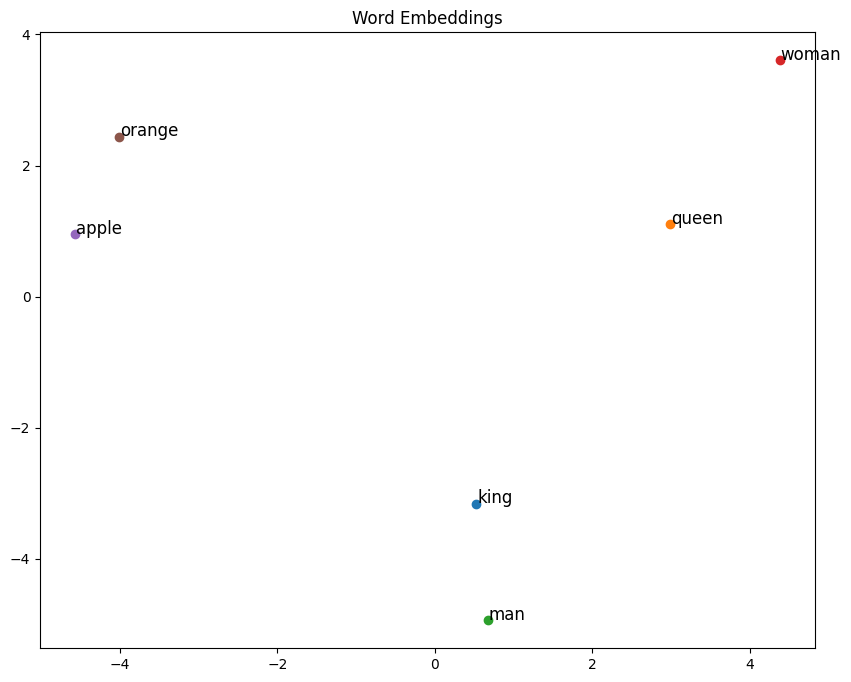

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nlp = spacy.load("en_core_web_md")

words = ["king", "queen", "man", "woman", "apple", "orange"]
# words = ["cat", "dog", "lion", "tiger", "car", "truck"]

# get vectors
vectors = [nlp(word).vector for word in words]

# Reduce dimensions
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Use t-SNE for 2D projection
# tsne = TSNE(n_components=2, perplexity=1, random_state=42)  
# vectors = np.array(vectors) # Convert list of vectors to NumPy array
# reduced = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(10, 8))
for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=12)

plt.title("Word Embeddings")
plt.show()
